In [ ]:
from typing import List, Tuple

import numpy as np
from qiskit.circuit.library import CXGate, SwapGate, iSwapGate
from scipy.optimize import linprog

from gulps.invariants import LEN_GATE_INVARIANTS, GateInvariants
from gulps.linear_program import MinimalOrderedISAConstraints
from gulps.qlr import len_qlr, qlr_inequalities

In [2]:
isa_sequence = [
    GateInvariants.from_unitary(iSwapGate().power(1 / 2)),
    GateInvariants.from_unitary(iSwapGate().power(1 / 2)),
    GateInvariants.from_unitary(iSwapGate().power(1 / 2)),
]
constraints = MinimalOrderedISAConstraints(isa_sequence)

<Axes3D: xlabel='$c_1$', ylabel='$c_2$', zlabel='$c_3$'>

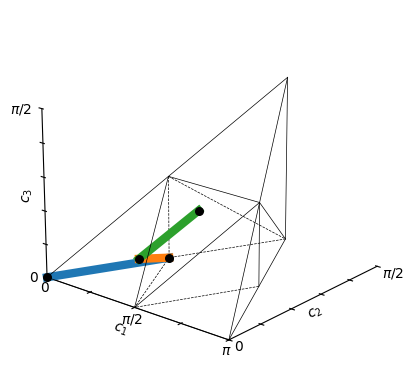

In [10]:
from gulps.visualize import render_path
from qiskit.quantum_info.random import random_unitary

u = random_unitary(4)
# u = SwapGate().to_matrix()
gi = GateInvariants.from_unitary(u)
constraints.set_target(gi)

sentence, intermediates = constraints.solve(log_output=False)
if sentence is None:
    constraints.set_target(gi.rho_reflect())
    sentence, intermediates = constraints.solve(log_output=False)

render_path(intermediates)